In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
M = (0.5)*0.001
m = (0.1)*(0.001)
g = 9.81
us = 0.0
uk = 0.0
w = (10*100)*(2*np.pi)/60
r = (0.002)/(np.sqrt(2))

In [47]:
T = np.linspace(0.001, 1, 1000000)
a = np.zeros(np.size(T))
v = np.zeros(np.size(T))
for i in range(np.size(T)):
  t = T[i]
  N = (M+m)*g + m*w*w*r*np.cos(w*t)
  Fx = m*w*w*r*np.sin(w*t)
  if v[i] == 0:
    if np.abs(N*us) > np.abs(Fx):
      a[i] = 0
    else:
      a[i] = (Fx/np.abs(Fx))*(np.abs(Fx) - np.abs(N*us))/(m+M)
  else:
    if np.abs(N*uk) > np.abs(Fx):
      a[i] = 0
    else:
      a[i] = (Fx/np.abs(Fx))*(np.abs(Fx) - np.abs(N*uk))/(m+M)
  if i != (np.size(T) - 1):
    v[i+1] = a[i]*(T[i+1]-T[i]) + v[i]

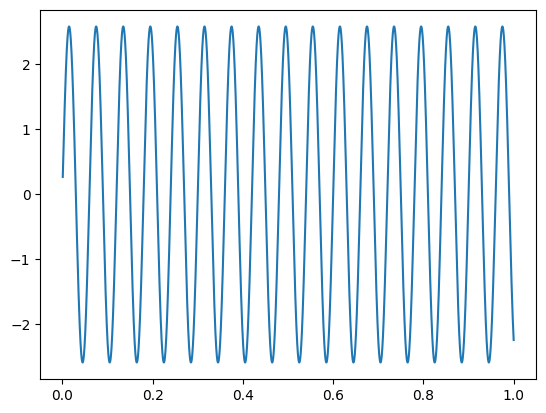

In [48]:
plt.plot(T, a)

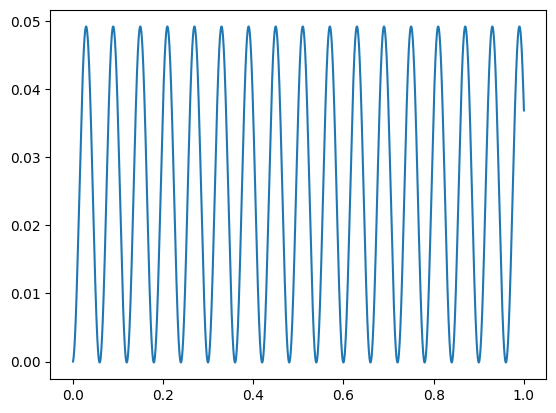

In [49]:
plt.plot(T, v)

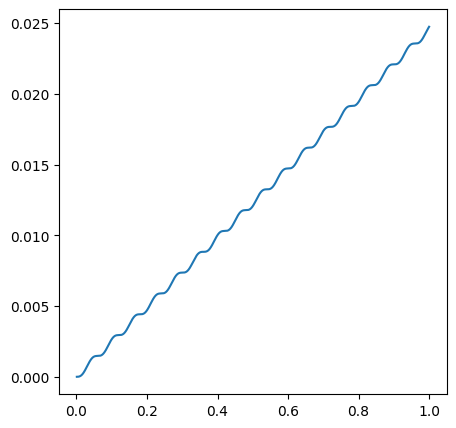

In [50]:
x = np.zeros(np.size(T))
plt.figure(figsize = (5, 5))
for i in range(1, np.size(T)):
  x[i] = x[i-1] + (0.5)*(v[i] + v[i-1])*(T[2]-T[1])
plt.plot(T, x)

Above was the 1-D case. Let's try the 2-D case now.

In [6]:
Mbot = 5
R = 4*(0.01)
k = 1e5
A = np.matrix('-2 0 1 0 1 0; 0 -2 0 1 0 1; 1 0 -2 0 1 0; 0 1 0 -2 0 1; 1 0 1 0 -2 0; 0 1 0 1 0 -2')
A = A*k
us = 0.9
uk = 0.8
print(A)
print(np.zeros((3, 2)))

[[-200000.       0.  100000.       0.  100000.       0.]
 [      0. -200000.       0.  100000.       0.  100000.]
 [ 100000.       0. -200000.       0.  100000.       0.]
 [      0.  100000.       0. -200000.       0.  100000.]
 [ 100000.       0.  100000.       0. -200000.       0.]
 [      0.  100000.       0.  100000.       0. -200000.]]
[[0. 0.]
 [0. 0.]
 [0. 0.]]


In [23]:
def get_friction(F1, F2, vel, x, N, cor):
  fr = np.zeros((3, 2))
  fa = np.array([F1+F2, 0, F1+F2, 0, F1+F2, 0])
  # x = np.array([vc[0] + r*np.cos(np.pi + phi), vc[1] + r*np.sin(np.pi + phi), vc[0] + r*np.cos((-2*np.pi/3) + phi), vc[1] + r*np.sin((-2*np.pi/3) + phi), vc[0] + r*np.cos((2*np.pi/3) + phi), vc[1] + r*np.sin((2*np.pi/3) + phi)])
  ff = -(np.matmul(x.reshape(6) , A) - cor.reshape(6)) - fa
  if vel[0].all() == 0:
    if np.linalg.norm(ff[0:2]) < N[0]*us:
      fr[0, :] = ff[0:2]
    else:
      fr[0, :] = (ff[0:2]/np.linalg.norm(ff[0:2]))*N[0]*us
  else:
    theta = np.arctan((vel[0])[1]/(vel[0])[0]) + np.pi
    fr[0, 0] = N[0]*uk*np.cos(theta)
    fr[0, 1] = N[0]*uk*np.sin(theta)

  if vel[1].all() == 0:
    if np.linalg.norm(ff[2:4]) < N[1]*us:
      fr[1, :] = ff[2:4]
    else:
      fr[1, :] = (ff[2:4]/np.linalg.norm(ff[2:4]))*N[1]*us
  else:
    theta = np.arctan((vel[1])[1]/(vel[1])[0]) + np.pi
    fr[1, 0] = N[1]*uk*np.cos(theta)
    fr[1, 1] = N[1]*uk*np.sin(theta)

  if vel[2].all() == 0:
    if np.linalg.norm(ff[4:6]) < N[2]*us:
      fr[2, :] = ff[4:6]
    else:
      fr[2, :] = (ff[4:6]/np.linalg.norm(ff[4:6]))*N[2]*us
  else:
    theta = np.arctan((vel[2])[1]/(vel[2])[0]) + np.pi
    fr[2, 0] = N[2]*uk*np.cos(theta)
    fr[2, 1] = N[2]*uk*np.sin(theta)

  return fr

In [24]:
def get_dynamics(F1, F2, vel, pos, N, h = 0.001):
  theta = np.zeros(3)
  for i in range(3):
    theta[i] = np.arctan((pos[(i+1)%3][1]-pos[i][1])/(pos[(i+1)%3][0] - pos[i][0]))
  cor = ((np.matrix([np.cos(theta[0]) + np.cos(theta[2]), np.sin(theta[0]) + np.sin(theta[2]), np.cos(theta[1]) + np.cos(theta[0]), np.sin(theta[1]) + np.sin(theta[0]), np.cos(theta[2]) + np.cos(theta[1]), np.sin(theta[2]) + np.sin(theta[1])])).reshape((3,2)))*np.sqrt(3)*R*k
  # np.resize modifies the matrix in place, and returns NoneType. np.reshape returns the modified matrix.
  fr = get_friction(F1, F2, vel, pos, N, cor)
  pos2 = pos + h*vel
  vel2 = np.zeros((3,2))
  fs = (np.matmul(pos.reshape(6), A)) - cor.reshape(6)
  for i in range(3):
    acc = fr[i] + np.array([F1+F2, 0]) + fs[2*i:2*(i+1)]
    vel2[i] = vel[i] + h*acc
  return (pos2, vel2)

In [25]:
A1 = 1
A2 = 1
T = np.linspace(0.001, 1, 1000000)
vel = np.zeros((np.size(T), 3, 2))
pos = np.zeros((np.size(T), 3, 2))
Ntot = Mbot*g + m*w*w*r*np.cos(w*T)

for i in range(1, np.size(T)):
  t = T[i-1]
  F1 = A1*m*w*w*r*np.sin(w*t)
  F2 = A2*m*w*w*r*np.sin(w*t)
  xcom = (pos[i-1, 0, 0] + pos[i-1, 1, 0] + pos[i-1, 2, 0])/3
  ycom = (pos[i-1, 0, 1] + pos[i-1, 1, 1] + pos[i-1, 2, 1])/3
  phi = np.arctan((pos[i-1, 0, 1] - ycom)/(pos[i-1, 0, 0] - xcom))
  T = np.matrix([
    [1, 1, 1],
    [np.sin(np.pi + phi), np.sin(phi - np.pi/3), np.sin(phi + np.pi/3)],
    [np.cos(np.pi + phi), np.cos(phi - np.pi/3), np.cos(phi + np.pi/3)]
])
  T1 = np.linalg.inv(T)
  N = (np.matmul(T1, np.array([Ntot[i-1], 0, 0]))).reshape(3)
  pos[i] , vel[i] = get_dynamics(F1, F2, vel[i-1], pos[i-1], N, T[2] - T[1])

x = pos[:, :, 0]
y = pos[:, :, 1]
xcom = (x[:, 0] + x[:, 1] + x[:, 2])/3
ycom = (y[:, 0] + y[:, 1] + y[:, 2])/3
plt.figure(figsize = (5, 5))
plt.plot(xcom, ycom)

/tmp/ipykernel_11262/3384364235.py:14: RuntimeWarning: invalid value encountered in scalar divide
  phi = np.arctan((pos[i-1, 0, 1] - ycom)/(pos[i-1, 0, 0] - xcom))
/tmp/ipykernel_11262/2480566871.py:4: RuntimeWarning: invalid value encountered in scalar divide
  theta[i] = np.arctan((pos[(i+1)%3][1]-pos[i][1])/(pos[(i+1)%3][0] - pos[i][0]))


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()